In [ ]:
from shapely import wkb
import numpy as np
import pandas as pd
import geopandas as gpd
import skgstat as skg
import contextily as cx

from src.tools.databases.data_connection.connection import DBConnection
from src.databases.silver.aneel.config import CONTRACT_SILVER_ENERGY, YEARS
from src.tools.utils.common import get_db_path
from src.tools.utils.constants import CRS_GLOBAL        


PATHS = [get_db_path(CONTRACT_SILVER_ENERGY[f"aneel_kring_hexagon_grp_{year}"]) for year in YEARS]
CODIGO_IBGE = '3509502'  # Piracicaba, SP

In [184]:
conn = DBConnection("silver")
df = pd.DataFrame()
for i, (path, year) in enumerate(zip(PATHS, YEARS)):
    temp_df = conn.query_database(f"""SELECT hex_col, geometry, energy_consumption_residencial_urbano as energy_{year} FROM {path} WHERE cd_mun = '{CODIGO_IBGE}' AND are_loc = 'UB'""")
    temp_df['geometry'] = temp_df['geometry'].apply(wkb.loads) # type: ignore
    temp_df = gpd.GeoDataFrame(temp_df, geometry='geometry', crs=CRS_GLOBAL)
    # temp_df['geometry_degrees'] = temp_df['geometry'].to_crs(epsg=3857)
    df = pd.merge(df, temp_df, on=['hex_col', 'geometry'], how='outer') if not df.empty else temp_df
df["energy_sum"] = df.filter(like='energy_').sum(axis=1)
df = df[df["energy_sum"] > 0]

In [185]:
df.head()

,hex_col,geometry,energy_2017,energy_2018,energy_2019,energy_2020,energy_2021,energy_2022,energy_2023,energy_sum
0,8aa81141260ffff,"POLYGON ((-47.12533 -23.05368, -47.12473 -23.0...",23283.0,20477.000,14821.000,13561.050,11883.651,15081.736,13234.000,112341.437
1,8aa81141261ffff,"POLYGON ((-47.12402 -23.05352, -47.12342 -23.0...",1817.0,1726.000,1702.000,1680.062,0.000,0.000,1855.000,8780.062
2,8aa811412647fff,"POLYGON ((-47.12749 -23.05291, -47.12689 -23.0...",NaN,2203.877,10173.000,1392.452,1434.000,530.086,743.579,16476.994
3,8aa81141264ffff,"POLYGON ((-47.12833 -23.05199, -47.12774 -23.0...",NaN,6754.369,61367.628,68377.952,57920.000,45818.093,NaN,240238.042
4,8aa811412657fff,"POLYGON ((-47.12617 -23.05276, -47.12558 -23.0...",7721.0,9225.000,6298.000,8399.388,6554.744,4869.169,8989.132,52056.433


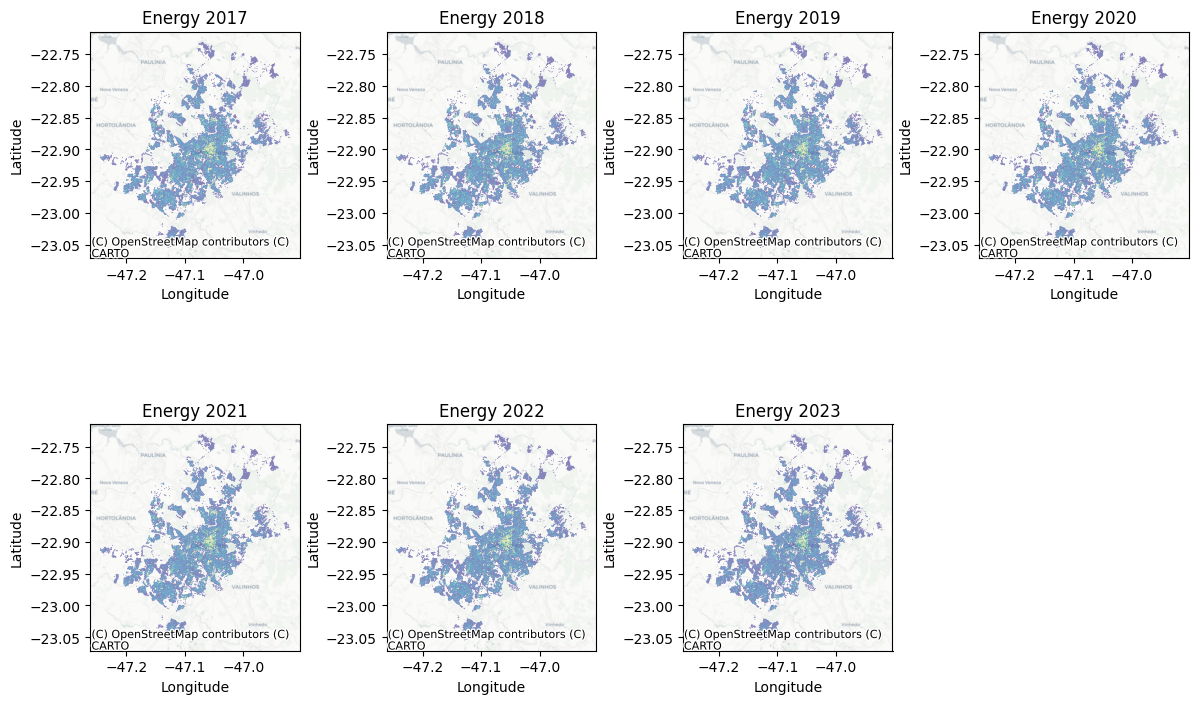

In [186]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

for i, year in enumerate(YEARS):
    ax = axes[i]
    df.plot(column=f"energy_{year}", cmap="Spectral_r", ax=ax, legend=False)
    ax.set_title(f"Energy {year}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)

# Hide the last subplot if there are fewer plots than subplots
if len(YEARS) < len(axes):
    for j in range(len(YEARS), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

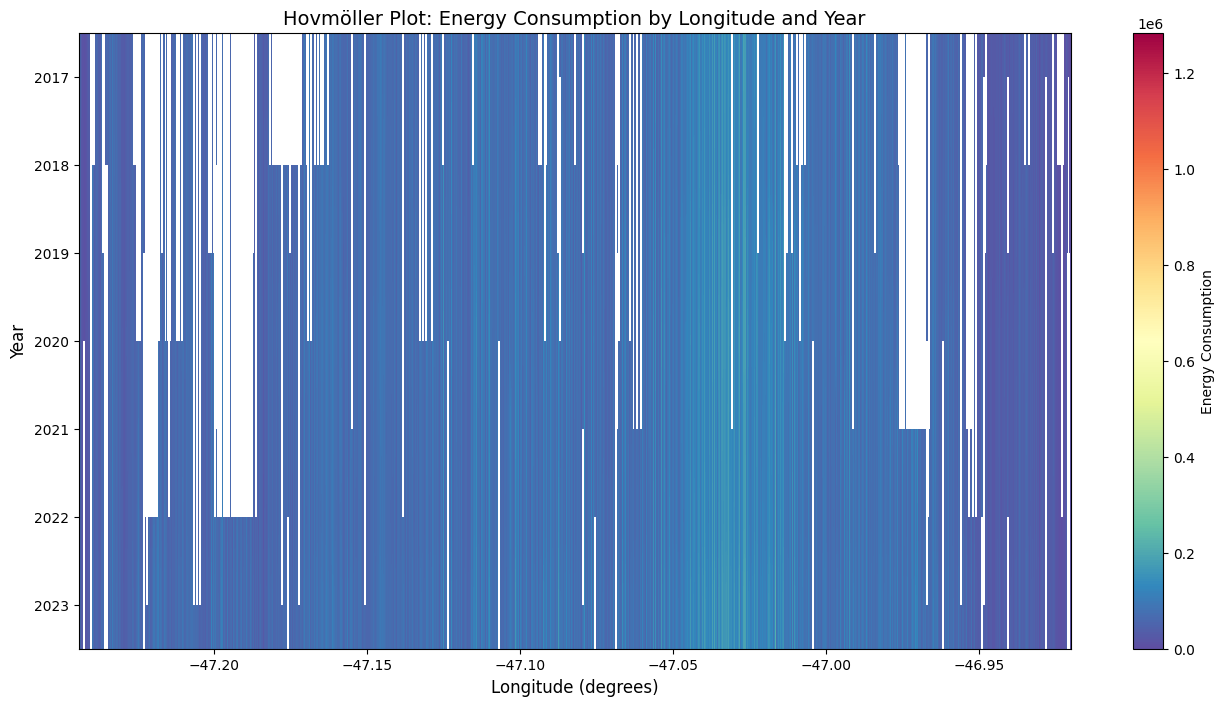

In [187]:
import numpy as np
import matplotlib.pyplot as plt

# Extract longitude and energy data
df["longitude"] = df["geometry"].centroid.x
hovmoller_data = np.array([df.groupby("longitude")[f"energy_{year}"].mean() for year in YEARS])

# Create the Hovmöller plot with better spacing
plt.figure(figsize=(16, 8))  # Increase figure size
plt.imshow(hovmoller_data, aspect='auto', cmap='Spectral_r', extent=[df["longitude"].min(), df["longitude"].max(), YEARS[-1] + 0.5, YEARS[0] - 0.5])
plt.colorbar(label="Energy Consumption")
plt.title("Hovmöller Plot: Energy Consumption by Longitude and Year", fontsize=14)
plt.xlabel("Longitude (degrees)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


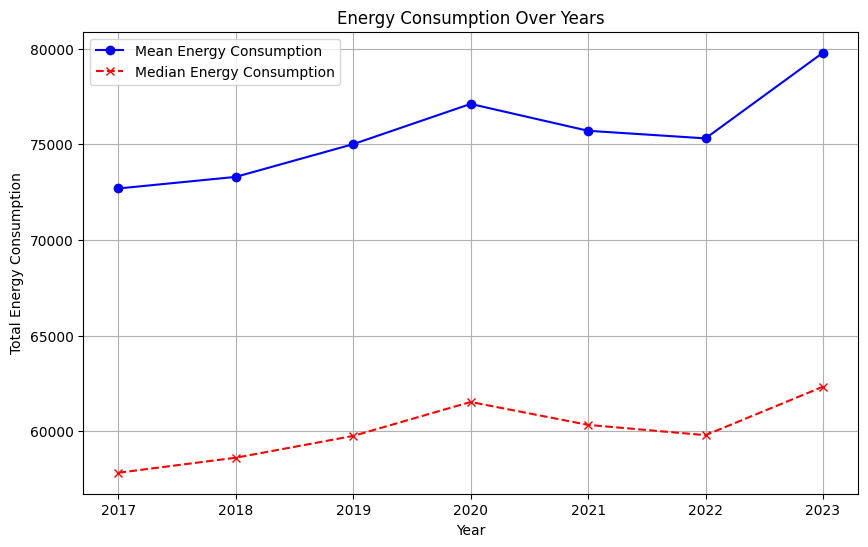

In [188]:

# Extract years and corresponding energy values
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023]
energy_values_mean = [df[f"energy_{year}"].mean() for year in years]
energy_values_median = [df[f"energy_{year}"].median() for year in years]
# Plot
plt.figure(figsize=(10, 6))
plt.plot(years, energy_values_mean, marker='o', linestyle='-', color='b')
plt.plot(years, energy_values_median, marker='x', linestyle='--', color='r')
plt.legend(['Mean Energy Consumption', 'Median Energy Consumption'])
plt.title("Energy Consumption Over Years")
plt.xlabel("Year")
plt.ylabel("Total Energy Consumption")
plt.grid(True)
plt.show()

In [189]:
# Extrair coordenadas em metros
coords = [(polygon.centroid.x, polygon.centroid.y) for polygon in df.geometry]

<Axes: >

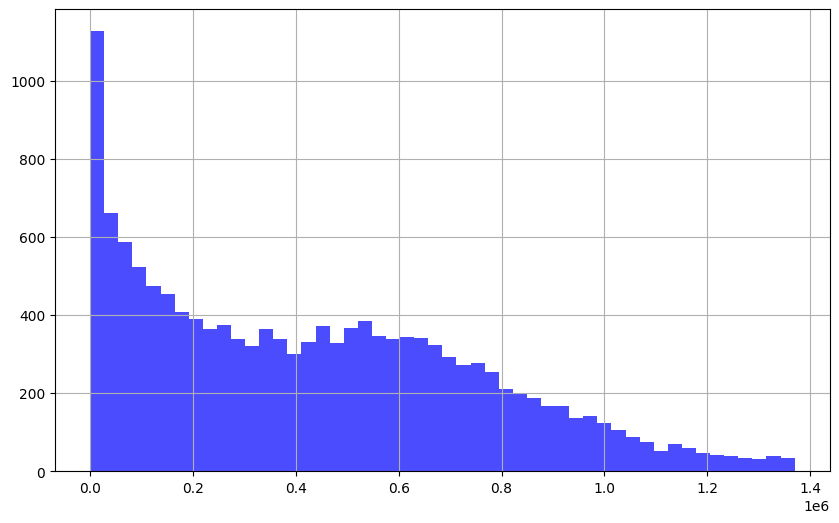

In [190]:
# Remove extreme values (e.g., values beyond the 99th percentile)
filtered_df = df[df["energy_sum"] <= df["energy_sum"].quantile(0.95)]

# Plot histogram with increased bins
filtered_df["energy_sum"].hist(bins=50, figsize=(10, 6), color='blue', alpha=0.7)

In [191]:
variogram = skg.Variogram(coordinates=coords, values=np.log(df["energy_sum"]))

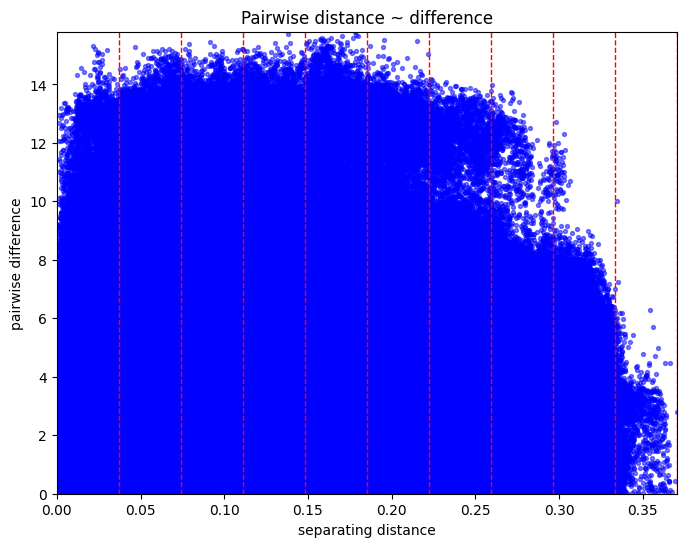

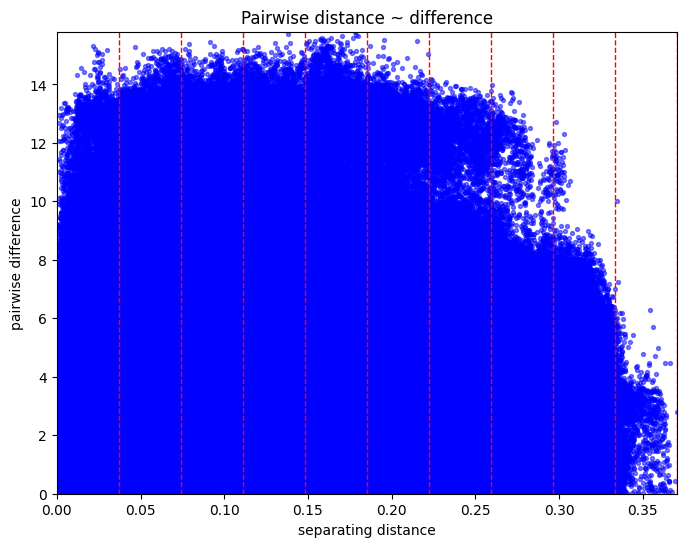

In [192]:
variogram.distance_difference_plot()

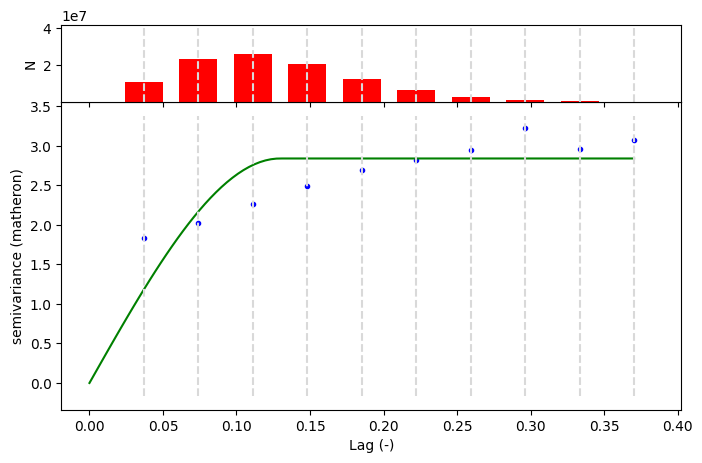

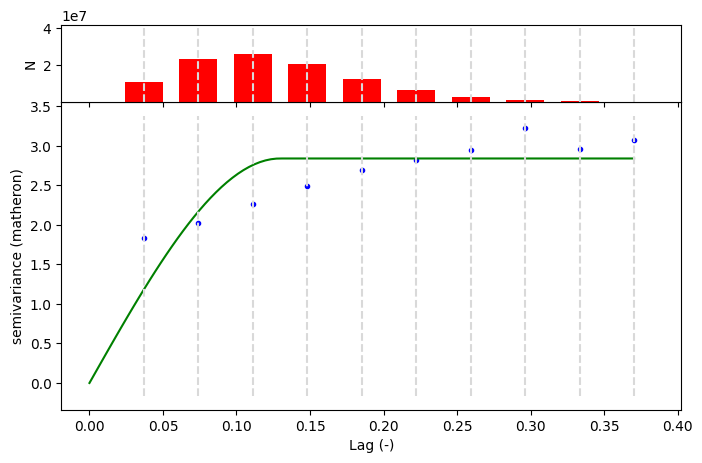

In [193]:
variogram.plot()

<Axes: xlabel='latitude', ylabel='energy_sum'>

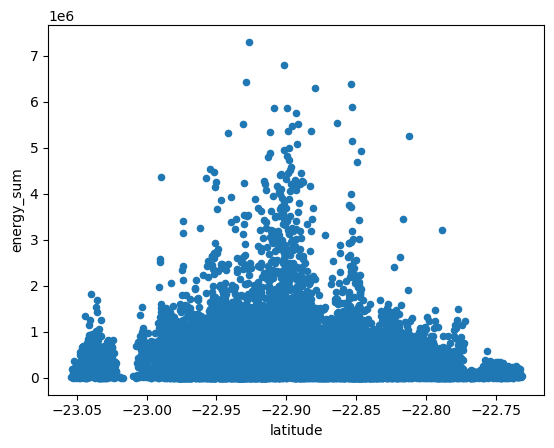

In [194]:
df["latitude"] = df["geometry"].centroid.y
df.plot(x="latitude", y="energy_sum", kind="scatter")

<Axes: xlabel='longitude', ylabel='energy_sum'>

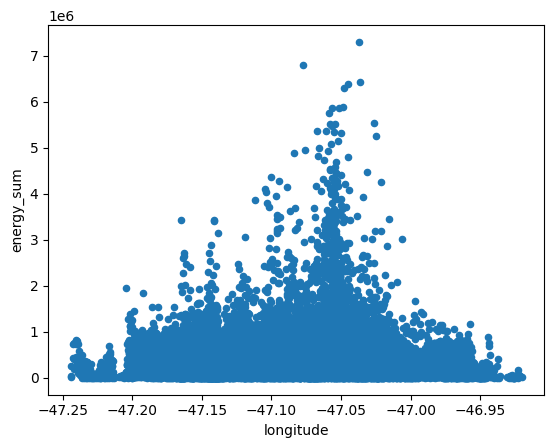

In [195]:
df["longitude"] = df["geometry"].centroid.x
df.plot(x="longitude", y="energy_sum", kind="scatter")